# Testing the draft 2D scatter plot (`new_graphics/scatter.py`)

This notebook exercises `make_scatter()`, the draft implementation of the new scatter
plot type. Plain scatter serves the Continuous x Continuous cell of the 2D lookup
table; the `jitter="orderly"` mode (sections 5–6) serves the Discrete x Discrete cell.
It is **not** wired into `.plot()` yet — this is for visually checking the draft before
integration.

**How to run:** use the `symbulate` conda environment (the draft imports helpers from
`symbulate.plot`, which is only installed there), then Run All. The setup cell finds the
repo root on its own, so it doesn't matter which folder Jupyter was launched from — and
it reloads `scatter.py` every time it runs, so after editing the draft just Run All
again; no kernel restart needed. Its printout shows which constants are loaded, so you
can confirm the kernel matches the file.

**What to look for in every plot:**
- Filled circles in the series color at alpha 0.25, so overlapping points stay
  readable while a lone point still reads as solid (note: this overrides the
  finalized Visual Style Guide's *unfilled* scatter decision — flagged for the
  decision log)
- Light horizontal reference grid behind the points; no top or right spines
- Axes labeled "Variable 1" / "Variable 2" by default, overridable with
  `xlabel=` / `ylabel=`
- Overlays get distinct Okabe-Ito colors (sky blue first, then orange) and an
  automatic "Variable k" legend in the top right
- With `jitter="orderly"` (discrete data): grid lines move to the half-integer bin
  boundaries, and coincident points fill a neat sub-grid inside each bin cell

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder holding symbulate/symbulate.mplstyle),
# so the notebook works no matter where Jupyter was launched from.
REPO_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helper and its per-plot-type constants. The reload makes
# re-running this cell pick up the latest scatter.py even in a kernel
# that already imported an older version -- no kernel restart needed
# while the draft is being iterated on.
import scatter

importlib.reload(scatter)
from scatter import make_scatter, SCATTER_ALPHA, SCATTER_MARKER_SIZE
from symbulate.plot import get_next_color

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Applied *after* the imports above: importing symbulate currently switches
# matplotlib back to the old seaborn/ggplot stylesheet (a Phase 2 item).
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"SCATTER_ALPHA = {SCATTER_ALPHA}, SCATTER_MARKER_SIZE = {SCATTER_MARKER_SIZE}")

SCATTER_ALPHA = 0.25, SCATTER_MARKER_SIZE = 40


## 1. Reproduce the approved prototype

A single scatter of two positively correlated continuous variables, matching the
prototype image: points trending up and to the right, x-axis "Variable 1",
y-axis "Variable 2", no legend (a lone scatter doesn't need one). The first
color in the cycle is sky blue (`#56B4E9`).

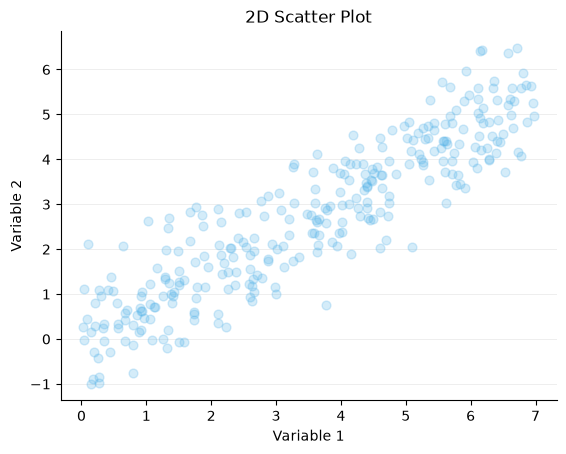

In [2]:
x = rng.uniform(0, 7, 300)
y = 0.8 * x + rng.normal(0, 0.8, 300)

ax = plt.gca()
make_scatter(x, y, ax, get_next_color(ax))
plt.show()

## 2. Options: transparency, custom axis and series labels

`alpha=` overrides the 0.25 default (useful for small samples, where fewer
points overlap); `xlabel=` / `ylabel=` rename the axes; `label=` names the
series in the legend once there is more than one.

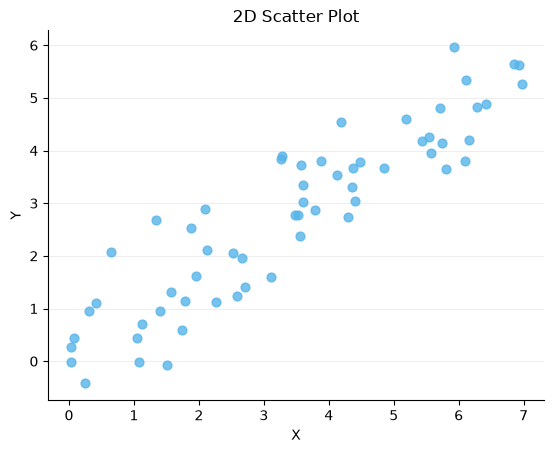

In [3]:
ax = plt.gca()
make_scatter(x[:60], y[:60], ax, get_next_color(ax), alpha=0.8, xlabel="X", ylabel="Y")
plt.show()

## 3. Overlay behavior — mimicking two `.plot()` calls

A second scatter on the same axes picks up the next Okabe-Ito color (orange)
and turns on the "Variable k" legend automatically. The open circles and low
alpha should keep the overlap region readable — you can still trace each cloud
through the other.

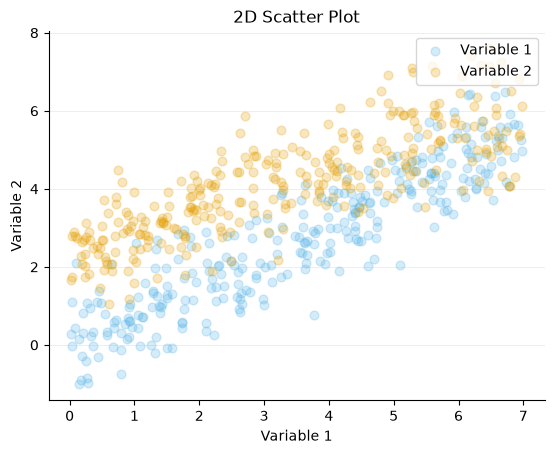

In [4]:
x2 = rng.uniform(0, 7, 300)
y2 = 0.5 * x2 + rng.normal(2.5, 0.8, 300)

ax = plt.gca()
make_scatter(x, y, ax, get_next_color(ax))
make_scatter(x2, y2, ax, get_next_color(ax))
plt.show()

## 4. With real symbulate simulation data

Same draft, but the data comes from an actual 2D `RV(...).sim(...)` call —
a bivariate normal with correlation 0.7, so the cloud should tilt clearly.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

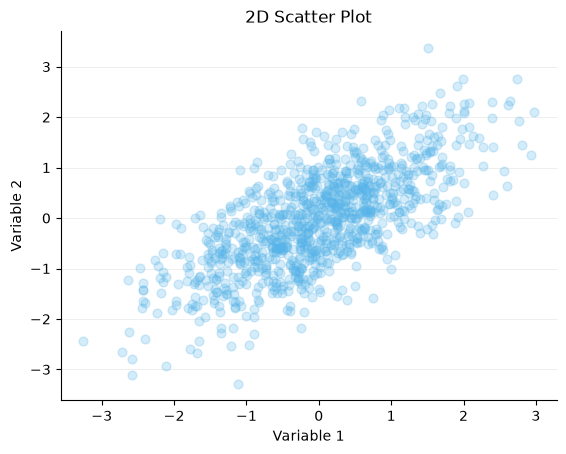

In [5]:
from symbulate import RV, BivariateNormal

sims = RV(BivariateNormal(mean1=0, mean2=0, sd1=1, sd2=1, corr=0.7)).sim(1000)
arr = np.asarray(sims.results)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_scatter(arr[:, 0], arr[:, 1], ax, get_next_color(ax))
plt.show()

## 5. Discrete x Discrete: orderly jitter with bin cells

For two discrete variables, many points land on the exact same integer
`(x, y)`, so a plain scatter collapses them into one dot and random jitter
(`jitter=True`) scrambles the density. `jitter="orderly"` instead lays the
points sharing a cell out in a neat centered sub-grid and moves the grid lines
to the half-integer **bin boundaries**, so each integer sits centered in its own
cell and you can read the density by counting the dots in each cell.

Compare the two cells below: random jitter first, then orderly.

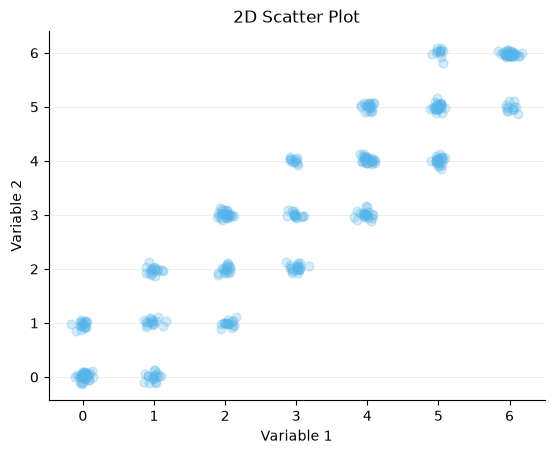

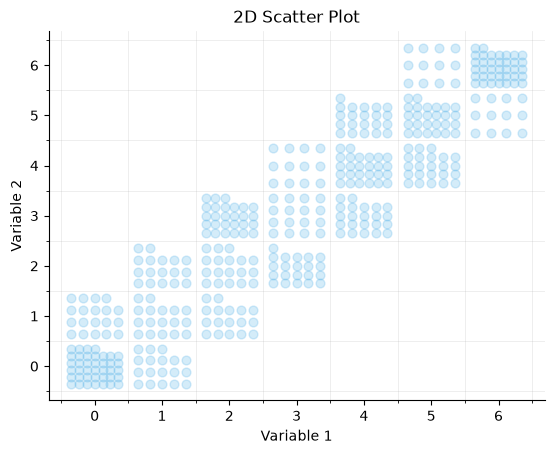

In [6]:
# Positively correlated integer data (e.g. two dependent discrete counts).
xd = rng.integers(0, 7, 400)
yd = np.clip(xd + rng.integers(-1, 2, 400), 0, 6)

# Random jitter: reduces overplotting but the density is impossible to read.
ax = plt.gca()
make_scatter(xd, yd, ax, get_next_color(ax), jitter=True)
plt.show()

# Orderly jitter: coincident points fill a countable sub-grid, and the grid
# lines mark the bin boundaries around each integer.
ax = plt.gca()
make_scatter(xd, yd, ax, get_next_color(ax), jitter="orderly")
plt.show()

## 6. Orderly jitter on real symbulate discrete data

The discrete parallel of section 4: the data comes from an actual 2D discrete
`RV(...).sim(...)` — two independent `Binomial(6, 0.5)` counts, so probability
piles up in the central cells. With `jitter="orderly"`, the busy middle cells
fill large countable sub-grids while the corner cells hold just a point or two,
making the joint distribution's shape readable at a glance.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

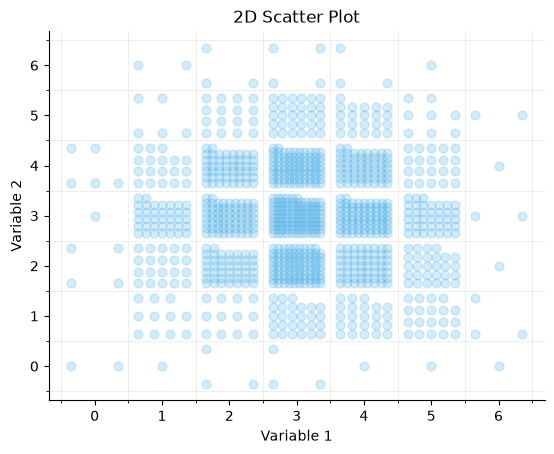

In [7]:
from symbulate import RV, Binomial

# Two independent Binomial(6, 0.5) counts -> a 2D discrete simulation.
disc_sims = RV(Binomial(6, 0.5) ** 2).sim(1000)
disc = np.asarray(disc_sims.results)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_scatter(disc[:, 0], disc[:, 1], ax, get_next_color(ax), jitter="orderly")
plt.show()

## Verification checklist

- [ ] Section 1 matches the approved prototype image (sky blue, upward trend, no legend)
- [ ] Points are filled circles in the series color; overlap regions stay readable
- [ ] Grid behind the points; no top/right spines
- [ ] `alpha=`, `xlabel=`, `ylabel=`, and `label=` overrides work
- [ ] Overlaid scatters get distinct Okabe-Ito colors and the automatic "Variable k" legend
- [ ] Works on real 2D `.sim()` output, not just numpy arrays
- [ ] Correlated bivariate normal data shows a clearly tilted cloud
- [ ] `jitter="orderly"`: grid lines sit at the half-integer bin boundaries, integers centered in cells
- [ ] Orderly cells hold neat countable sub-grids; busy cells are visibly fuller than sparse ones
- [ ] Orderly layout is deterministic — re-running gives the identical arrangement